# Borough-Level Vacancy & Land Cover Analysis

Determines the spatial train/val/test split by quantifying:
1. **Vacancy pixel counts** per borough (from existing masks)
2. **Land cover composition** of vacant pixels per borough (three independent sources)

**Land cover sources:**
- NLCD 2021 (30 m, USGS) — via GEE
- Dynamic World 2022 (10 m, Google/WRI, Sentinel-2) — via GEE
- Esri 10m LULC 2022 (10 m, Esri, Sentinel-2) — via Planetary Computer

The goal is to assign boroughs to splits that maximise surface-type diversity
in training while keeping spatially independent test data.

**Inputs:**
- `outputs/masks/nyc_buildings/vacancy_mask.tif` — 0/1/255
- `outputs/masks/nyc_buildings/borough_mask.tif` — 1-5

**Outputs:**
- Vacancy summary table (borough × pixel counts)
- Land cover cross-tabulation + stacked bar chart per source
- Side-by-side three-way comparison
- Split recommendation

## Imports & Config

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vacant_lot.config import load_config, _get_shared_root
from vacant_lot.label_utils import (
    BOROUGH_NAMES,
    analyze_borough_vacancy,
    characterize_vacant_land_cover,
)
from vacant_lot.plotting import save_figure

SHARED_ROOT = _get_shared_root()
cfg = load_config("nyc_buildings.yaml")

masks_dir = cfg.get_seg_masks_dir()
vacancy_mask_path = masks_dir / "vacancy_mask.tif"
borough_mask_path = masks_dir / "borough_mask.tif"

# Land cover GeoTIFFs (downloaded in Step 2 below)
lc_dir = SHARED_ROOT / "data" / "land_cover" / "nyc"
nlcd_path = lc_dir / "nlcd_nyc_2021.tif"
dw_path = lc_dir / "dynamic_world_nyc_2022.tif"
esri_path = lc_dir / "esri_lulc_nyc_2022.tif"

print(f"Vacancy mask: {vacancy_mask_path}")
print(f"Borough mask: {borough_mask_path}")
print(f"Land cover dir: {lc_dir}")

---
# Step 1 — Borough Vacancy Pixel Counts

Count vacant / non-vacant / ignore pixels per borough from the existing masks.

In [ ]:
vacancy_df = analyze_borough_vacancy(vacancy_mask_path, borough_mask_path)
vacancy_df.style.format({
    "Vacant Pixels": "{:,.0f}",
    "Non-Vacant Pixels": "{:,.0f}",
    "Ignore (255)": "{:,.0f}",
    "Vacant Fraction": "{:.4f}",
})

21:02:22 | INFO | vacant_lots | 
      Borough  Vacant Pixels  Non-Vacant Pixels  Ignore (255)  Vacant Fraction
    Manhattan        2533903          114832824     110691263         0.021590
        Bronx        8395107          215235595     118163861         0.037540
     Brooklyn       10663362          348970389     210689552         0.029651
       Queens       19388764          565271383     300554251         0.033162
Staten Island       50954022          275561372      88467292         0.156054


,Borough,Vacant Pixels,Non-Vacant Pixels,Ignore (255),Vacant Fraction
0,Manhattan,"2,533,903","114,832,824","110,691,263",0.0216
1,Bronx,"8,395,107","215,235,595","118,163,861",0.0375
2,Brooklyn,"10,663,362","348,970,389","210,689,552",0.0297
3,Queens,"19,388,764","565,271,383","300,554,251",0.0332
4,Staten Island,"50,954,022","275,561,372","88,467,292",0.1561


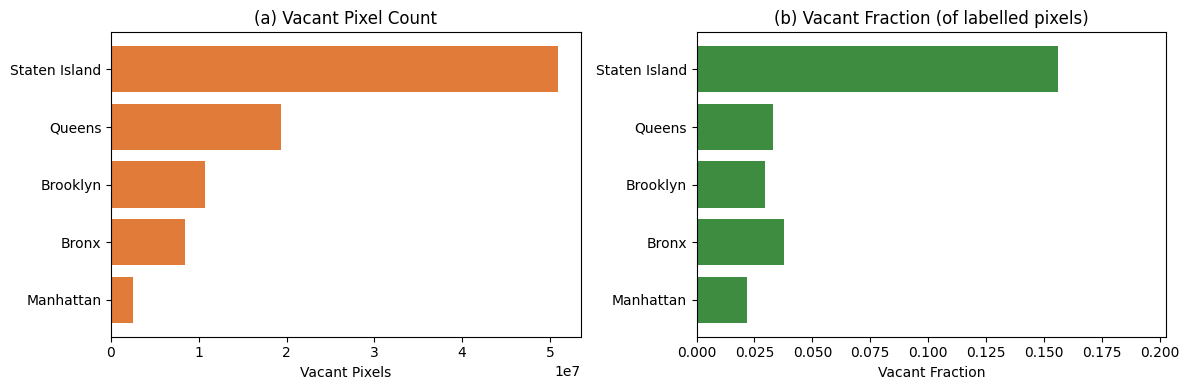

In [ ]:
# Bar chart of vacant fraction by borough
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Absolute vacant pixel counts
axes[0].barh(vacancy_df["Borough"], vacancy_df["Vacant Pixels"], color="#e07b39")
axes[0].set_xlabel("Vacant Pixels")
axes[0].set_title("(a) Vacant Pixel Count")
axes[0].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

# (b) Vacant fraction
axes[1].barh(vacancy_df["Borough"], vacancy_df["Vacant Fraction"], color="#3d8c40")
axes[1].set_xlabel("Vacant Fraction")
axes[1].set_title("(b) Vacant Fraction (of labelled pixels)")
axes[1].set_xlim(0, vacancy_df["Vacant Fraction"].max() * 1.3)

plt.tight_layout()
plt.show()

---
# Step 2 — Download Land Cover Rasters

Export three land cover products for the NYC extent as local GeoTIFFs:
- **NLCD 2021** (30 m, USGS) — via GEE
- **Dynamic World 2022** (10 m, Google/WRI) — via GEE
- **Esri 10m LULC 2022** (10 m, Esri) — via Planetary Computer (no GEE)

> **Run once** — each cell skips if the file already exists.

In [ ]:
import ee
from vacant_lot.gee_utils import init_gee

init_gee(cfg.gcp)

# NYC bounding box (WGS84) from config
bbox = cfg.segmentation.bbox  # [west, south, east, north]
roi = ee.Geometry.Rectangle(bbox)

lc_dir.mkdir(parents=True, exist_ok=True)

### 2a — NLCD 2021

NLCD land cover at 30 m resolution. Key classes:
- 21: Developed, Open Space
- 22: Developed, Low Intensity
- 23: Developed, Medium Intensity
- 24: Developed, High Intensity
- 31: Barren Land
- 41-43: Forest (Deciduous/Evergreen/Mixed)
- 52: Shrub/Scrub
- 71: Grassland/Herbaceous
- 90/95: Wetlands

In [ ]:
import geemap

if nlcd_path.exists():
    print(f"NLCD already downloaded: {nlcd_path}")
else:
    nlcd = ee.Image("USGS/NLCD_RELEASES/2021_REL/NLCD/2021").select("landcover")
    nlcd_clipped = nlcd.clip(roi)

    geemap.ee_export_image(
        nlcd_clipped,
        filename=str(nlcd_path),
        scale=30,
        region=roi,
        file_per_band=False,
    )
    print(f"NLCD downloaded: {nlcd_path}")

### 2b — Dynamic World 2022

Sentinel-2 derived land cover at 10 m resolution. Filtered to the NAIP
acquisition window (July–September 2022) rather than a full-year composite,
so the land cover snapshot matches what the NAIP imagery actually shows.

Classes: 0=Water, 1=Trees, 2=Grass, 3=Flooded Veg, 4=Crops, 5=Shrub/Scrub,
6=Built, 7=Bare, 8=Snow/Ice.

In [ ]:
if dw_path.exists():
    print(f"Dynamic World already downloaded: {dw_path}")
else:
    import rasterio
    from rasterio.merge import merge as rio_merge

    # Mode composite over NAIP acquisition window (Jul 19 – Sep 15, 2022)
    dw_col = (
        ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
        .filterDate("2022-07-19", "2022-09-16")
        .filterBounds(roi)
        .select("label")
    )
    print(f"Dynamic World scenes in window: {dw_col.size().getInfo()}")
    dw_mode = dw_col.reduce(ee.Reducer.mode()).clip(roi)

    # Split bbox into quadrants to stay under GEE 48MB download limit
    west, south, east, north = bbox
    mid_lon = (west + east) / 2
    mid_lat = (south + north) / 2
    quadrants = [
        ("sw", [west, south, mid_lon, mid_lat]),
        ("se", [mid_lon, south, east, mid_lat]),
        ("nw", [west, mid_lat, mid_lon, north]),
        ("ne", [mid_lon, mid_lat, east, north]),
    ]

    tile_paths = []
    for name, qbbox in quadrants:
        tile_path = lc_dir / f"_dw_tile_{name}.tif"
        q_roi = ee.Geometry.Rectangle(qbbox)
        print(f"Downloading Dynamic World quadrant {name}...")
        geemap.ee_export_image(
            dw_mode.clip(q_roi),
            filename=str(tile_path),
            scale=10,
            region=q_roi,
            file_per_band=False,
        )
        tile_paths.append(tile_path)

    # Mosaic quadrants into single file
    datasets = [rasterio.open(p) for p in tile_paths]
    mosaic, out_transform = rio_merge(datasets)
    out_meta = datasets[0].meta.copy()
    out_meta.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_transform,
        "compress": "lzw",
    })
    for ds in datasets:
        ds.close()

    with rasterio.open(dw_path, "w", **out_meta) as dst:
        dst.write(mosaic)

    # Clean up tiles
    for p in tile_paths:
        p.unlink()

    print(f"Dynamic World downloaded: {dw_path}")

### 2c — Esri 10m LULC 2022

Sentinel-2 derived land cover at 10 m resolution from Microsoft Planetary Computer.
Same resolution as Dynamic World but different classification model — comparing
the two tests robustness of the land cover characterization.

Classes: 1=Water, 2=Trees, 4=Flooded Veg, 5=Crops, 7=Built Area,
8=Bare Ground, 9=Snow/Ice, 10=Clouds, 11=Rangeland.

In [ ]:
if esri_path.exists():
    print(f"Esri LULC already downloaded: {esri_path}")
else:
    import planetary_computer
    import pystac_client
    import rasterio
    from rasterio.windows import from_bounds
    from rasterio.crs import CRS

    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )
    search = catalog.search(
        collections=["io-lulc-annual-v02"],
        bbox=bbox,
        datetime="2022-01-01/2022-12-31",
    )
    items = list(search.items())
    print(f"Found {len(items)} Esri LULC tiles for NYC 2022")

    # Read just the NYC extent from the COG (windowed read over HTTPS)
    # Items may span multiple UTM tiles — read and mosaic
    from rasterio.merge import merge as rio_merge
    from rasterio.transform import from_bounds as transform_from_bounds

    tile_paths = []
    for i, item in enumerate(items):
        href = item.assets["data"].href
        tile_path = lc_dir / f"_esri_tile_{i}.tif"

        with rasterio.open(href) as src:
            # Transform bbox (WGS84) to the COG's CRS
            from rasterio.warp import transform_bounds
            src_bounds = transform_bounds(CRS.from_epsg(4326), src.crs, *bbox)
            window = from_bounds(*src_bounds, src.transform)

            # Clamp window to raster extent
            window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))

            data = src.read(1, window=window)
            win_transform = src.window_transform(window)

            with rasterio.open(
                tile_path, "w", driver="GTiff",
                height=data.shape[0], width=data.shape[1], count=1,
                dtype=data.dtype, crs=src.crs, transform=win_transform,
                compress="lzw",
            ) as dst:
                dst.write(data, 1)

        tile_paths.append(tile_path)
        print(f"  Tile {item.id}: {data.shape}")

    # Mosaic if multiple tiles, otherwise just rename
    if len(tile_paths) == 1:
        tile_paths[0].rename(esri_path)
    else:
        datasets = [rasterio.open(p) for p in tile_paths]
        mosaic, out_transform = rio_merge(datasets)
        out_meta = datasets[0].meta.copy()
        out_meta.update({
            "height": mosaic.shape[1], "width": mosaic.shape[2],
            "transform": out_transform, "compress": "lzw",
        })
        for ds in datasets:
            ds.close()
        with rasterio.open(esri_path, "w", **out_meta) as dst:
            dst.write(mosaic)
        for p in tile_paths:
            p.unlink()

    print(f"Esri LULC downloaded: {esri_path}")

---
# Step 3 — NLCD Land Cover Characterization of Vacant Pixels

In [ ]:
NLCD_CLASSES = {
    11: "Open Water",
    21: "Dev., Open Space",
    22: "Dev., Low Intensity",
    23: "Dev., Med Intensity",
    24: "Dev., High Intensity",
    31: "Barren Land",
    41: "Deciduous Forest",
    42: "Evergreen Forest",
    43: "Mixed Forest",
    52: "Shrub/Scrub",
    71: "Grassland",
    81: "Pasture/Hay",
    82: "Cultivated Crops",
    90: "Woody Wetlands",
    95: "Herbaceous Wetlands",
}

nlcd_df = characterize_vacant_land_cover(
    vacancy_mask_path, borough_mask_path, nlcd_path, NLCD_CLASSES
)
nlcd_df

21:03:10 | INFO | vacant_lots | 
      Borough  Open Water  Dev., Open Space  Dev., Low Intensity  Dev., Med Intensity  Dev., High Intensity  Barren Land  Deciduous Forest  Evergreen Forest  Mixed Forest  Shrub/Scrub  Grassland  Pasture/Hay  Cultivated Crops  Woody Wetlands  Herbaceous Wetlands    Total
    Manhattan       82535             59558                97529               406548               1802576            0             26026              1910             0            0      45348            0                 0               0                11873  2533903
        Bronx      152303            839141               918692              2363805               3785070         6858             54335             17293             0         4177      22056         1548                 0           11710               218119  8395107
     Brooklyn       93020            198887               527035              2214496               6729444        58574            165199             

,Borough,Open Water,"Dev., Open Space","Dev., Low Intensity","Dev., Med Intensity","Dev., High Intensity",Barren Land,Deciduous Forest,Evergreen Forest,Mixed Forest,Shrub/Scrub,Grassland,Pasture/Hay,Cultivated Crops,Woody Wetlands,Herbaceous Wetlands,Total
0,Manhattan,82535,59558,97529,406548,1802576,0,26026,1910,0,0,45348,0,0,0,11873,2533903
1,Bronx,152303,839141,918692,2363805,3785070,6858,54335,17293,0,4177,22056,1548,0,11710,218119,8395107
2,Brooklyn,93020,198887,527035,2214496,6729444,58574,165199,9991,7499,73340,28283,3244,0,203986,350364,10663362
3,Queens,298558,1231451,2441750,5365675,8633260,239879,261817,0,4373,95525,47840,0,0,74592,694044,19388764
4,Staten Island,770870,4394250,5367074,7095459,3629037,838309,7526899,2682,15562,270129,2404453,362341,22615,10606818,7647524,50954022


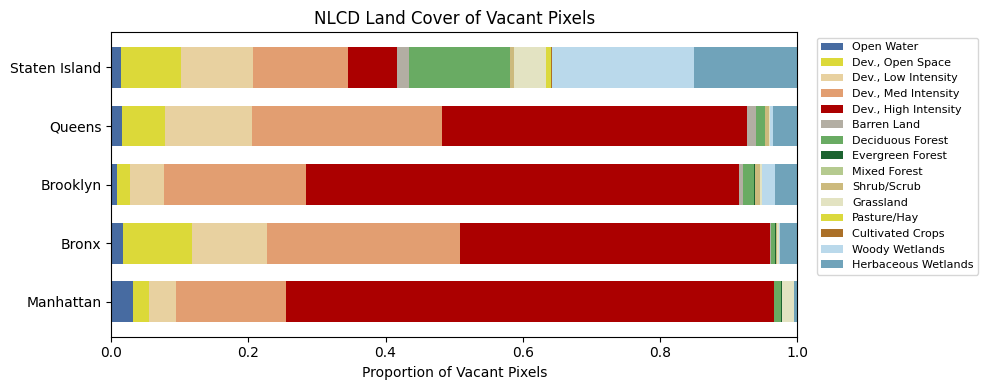

In [ ]:
# Stacked bar chart — land cover proportions per borough
def plot_land_cover_stacked(df, class_columns, title, colors=None, ax=None):
    """Plot stacked horizontal bar chart of land cover proportions."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    # Drop columns with all zeros
    nonzero_cols = [c for c in class_columns if c in df.columns and df[c].sum() > 0]

    # Compute proportions
    totals = df[nonzero_cols].sum(axis=1)
    props = df[nonzero_cols].div(totals, axis=0)

    # Build color list for non-zero columns
    plot_colors = None
    if colors is not None:
        plot_colors = [colors[c] for c in nonzero_cols if c in colors]

    props.plot.barh(stacked=True, ax=ax, width=0.7, color=plot_colors)
    ax.set_yticklabels(df["Borough"])
    ax.set_xlabel("Proportion of Vacant Pixels")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_xlim(0, 1)
    return ax


# NLCD official-ish palette
NLCD_COLORS = {
    "Open Water":           "#476ba1",
    "Dev., Open Space":     "#dcd939",
    "Dev., Low Intensity":  "#e8d1a0",
    "Dev., Med Intensity":  "#e29e71",
    "Dev., High Intensity": "#ab0000",
    "Barren Land":          "#b3aea3",
    "Deciduous Forest":     "#69ab63",
    "Evergreen Forest":     "#1c6330",
    "Mixed Forest":         "#b5ca8f",
    "Shrub/Scrub":          "#ccba7d",
    "Grassland":            "#e3e3c2",
    "Pasture/Hay":          "#dbd93d",
    "Cultivated Crops":     "#ab7028",
    "Woody Wetlands":       "#bad9eb",
    "Herbaceous Wetlands":  "#70a3ba",
}

fig, ax = plt.subplots(figsize=(10, 4))
plot_land_cover_stacked(
    nlcd_df, list(NLCD_CLASSES.values()), "NLCD Land Cover of Vacant Pixels",
    colors=NLCD_COLORS, ax=ax,
)
plt.tight_layout()
plt.show()

---
# Step 4 — Dynamic World Land Cover Characterization of Vacant Pixels

In [ ]:
DW_CLASSES = {
    0: "Water",
    1: "Trees",
    2: "Grass",
    3: "Flooded Veg",
    4: "Crops",
    5: "Shrub/Scrub",
    6: "Built",
    7: "Bare",
    8: "Snow/Ice",
}

dw_df = characterize_vacant_land_cover(
    vacancy_mask_path, borough_mask_path, dw_path, DW_CLASSES
)
dw_df

21:03:50 | INFO | vacant_lots | 
      Borough  Water    Trees   Grass  Flooded Veg   Crops  Shrub/Scrub    Built   Bare  Snow/Ice    Total
    Manhattan      0   105292   64728            0       0         2665  2097192    638         0  2270515
        Bronx      0   816556  246445        23305   18311            0  6810585  30198         0  7945400
     Brooklyn      0  1142467   26579            0       0            0  9141443  91308         0 10401797
       Queens      0  3214428   11110         9633   30254       143289 14357677 458604      7709 18232704
Staten Island      0 30697933 1396235      1219199 1137499      1095655 13487095  62626         0 49096242


,Borough,Water,Trees,Grass,Flooded Veg,Crops,Shrub/Scrub,Built,Bare,Snow/Ice,Total
0,Manhattan,0,105292,64728,0,0,2665,2097192,638,0,2270515
1,Bronx,0,816556,246445,23305,18311,0,6810585,30198,0,7945400
2,Brooklyn,0,1142467,26579,0,0,0,9141443,91308,0,10401797
3,Queens,0,3214428,11110,9633,30254,143289,14357677,458604,7709,18232704
4,Staten Island,0,30697933,1396235,1219199,1137499,1095655,13487095,62626,0,49096242


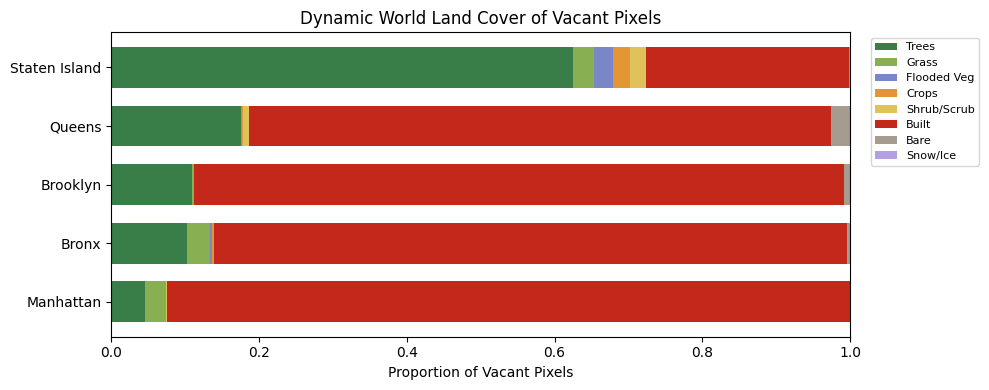

In [ ]:
DW_COLORS = {
    "Water":       "#419bdf",
    "Trees":       "#397d49",
    "Grass":       "#88b053",
    "Flooded Veg": "#7a87c6",
    "Crops":       "#e49635",
    "Shrub/Scrub": "#dfc35a",
    "Built":       "#c4281b",
    "Bare":        "#a59b8f",
    "Snow/Ice":    "#b39fe1",
}

fig, ax = plt.subplots(figsize=(10, 4))
plot_land_cover_stacked(
    dw_df, list(DW_CLASSES.values()), "Dynamic World Land Cover of Vacant Pixels",
    colors=DW_COLORS, ax=ax,
)
plt.tight_layout()
plt.show()

---
# Step 4b — Esri 10m LULC Characterization of Vacant Pixels

In [ ]:
ESRI_CLASSES = {
    1: "Water",
    2: "Trees",
    4: "Flooded Veg",
    5: "Crops",
    7: "Built Area",
    8: "Bare Ground",
    9: "Snow/Ice",
    10: "Clouds",
    11: "Rangeland",
}

esri_df = characterize_vacant_land_cover(
    vacancy_mask_path, borough_mask_path, esri_path, ESRI_CLASSES
)
esri_df

21:04:31 | INFO | vacant_lots | 
      Borough   Water    Trees  Flooded Veg  Crops  Built Area  Bare Ground  Snow/Ice  Clouds  Rangeland    Total
    Manhattan  163965     7772            0      0     2343304            0         0       0      18862  2533903
        Bronx  372621    97663            0  23009     7648727            0         0       0     253087  8395107
     Brooklyn  324723   676179            0      0     9333555        64365         0       0     264540 10663362
       Queens  918734  1333823        12493      0    15861703       208685         0       0    1053326 19388764
Staten Island 1789527 14947742      2345198  38438    22015462         1650         0       0    9816005 50954022


,Borough,Water,Trees,Flooded Veg,Crops,Built Area,Bare Ground,Snow/Ice,Clouds,Rangeland,Total
0,Manhattan,163965,7772,0,0,2343304,0,0,0,18862,2533903
1,Bronx,372621,97663,0,23009,7648727,0,0,0,253087,8395107
2,Brooklyn,324723,676179,0,0,9333555,64365,0,0,264540,10663362
3,Queens,918734,1333823,12493,0,15861703,208685,0,0,1053326,19388764
4,Staten Island,1789527,14947742,2345198,38438,22015462,1650,0,0,9816005,50954022


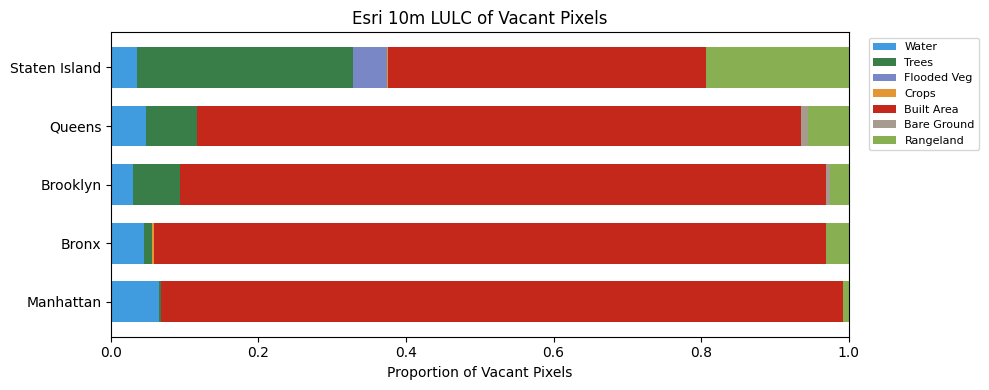

In [ ]:
ESRI_COLORS = {
    "Water":       "#419bdf",
    "Trees":       "#397d49",
    "Flooded Veg": "#7a87c6",
    "Crops":       "#e49635",
    "Built Area":  "#c4281b",
    "Bare Ground": "#a59b8f",
    "Snow/Ice":    "#b39fe1",
    "Clouds":      "#e8e8e8",
    "Rangeland":   "#88b053",
}

fig, ax = plt.subplots(figsize=(10, 4))
plot_land_cover_stacked(
    esri_df, list(ESRI_CLASSES.values()), "Esri 10m LULC of Vacant Pixels",
    colors=ESRI_COLORS, ax=ax,
)
plt.tight_layout()
plt.show()

---
# Step 5 — Side-by-Side Comparison

Compare all three land cover characterizations. Dynamic World and Esri LULC
are both 10 m / Sentinel-2 derived — agreement between them validates the
signal. NLCD at 30 m provides a coarser but independent reference.

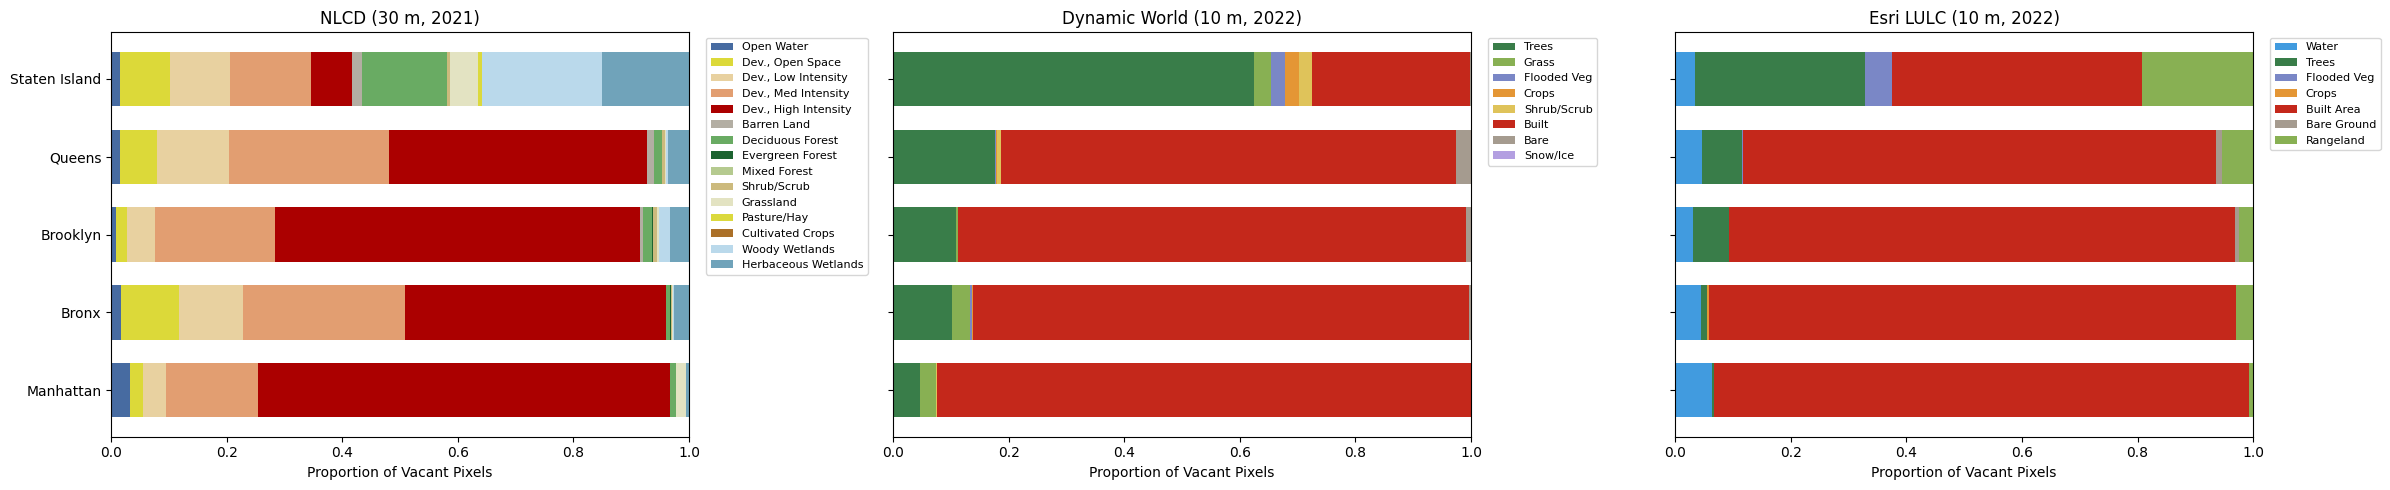

In [ ]:
# Side-by-side stacked bars — all three sources
fig, axes = plt.subplots(1, 3, figsize=(24, 5), sharey=True)

plot_land_cover_stacked(
    nlcd_df, list(NLCD_CLASSES.values()), "NLCD (30 m, 2021)",
    colors=NLCD_COLORS, ax=axes[0],
)
plot_land_cover_stacked(
    dw_df, list(DW_CLASSES.values()), "Dynamic World (10 m, 2022)",
    colors=DW_COLORS, ax=axes[1],
)
plot_land_cover_stacked(
    esri_df, list(ESRI_CLASSES.values()), "Esri LULC (10 m, 2022)",
    colors=ESRI_COLORS, ax=axes[2],
)

plt.tight_layout()
plt.show()

# save_figure(fig, cfg.get_final_figures_dir() / "borough_land_cover_comparison.png")

In [ ]:
# Proportion tables for easier comparison
print("=== NLCD Proportions ===")
nlcd_nonzero = [c for c in NLCD_CLASSES.values() if nlcd_df[c].sum() > 0]
nlcd_props = nlcd_df[nlcd_nonzero].div(nlcd_df["Total"], axis=0).round(3)
nlcd_props.insert(0, "Borough", nlcd_df["Borough"])
print(nlcd_props.to_string(index=False))

print("\n=== Dynamic World Proportions ===")
dw_nonzero = [c for c in DW_CLASSES.values() if dw_df[c].sum() > 0]
dw_props = dw_df[dw_nonzero].div(dw_df["Total"], axis=0).round(3)
dw_props.insert(0, "Borough", dw_df["Borough"])
print(dw_props.to_string(index=False))

print("\n=== Esri LULC Proportions ===")
esri_nonzero = [c for c in ESRI_CLASSES.values() if esri_df[c].sum() > 0]
esri_props = esri_df[esri_nonzero].div(esri_df["Total"], axis=0).round(3)
esri_props.insert(0, "Borough", esri_df["Borough"])
print(esri_props.to_string(index=False))